In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 
plt.rcParams["font.family"] = "Arial"  # Set global font to Arial

df = pd.read_csv("MOL_surface_adsorption_250427.csv", delimiter = ',')
unique_acid = df["Acid"].unique()
unique_acid = unique_acid[0:8]
unique_acid = np.delete(unique_acid, 3)     # delete 4th element (index 3)

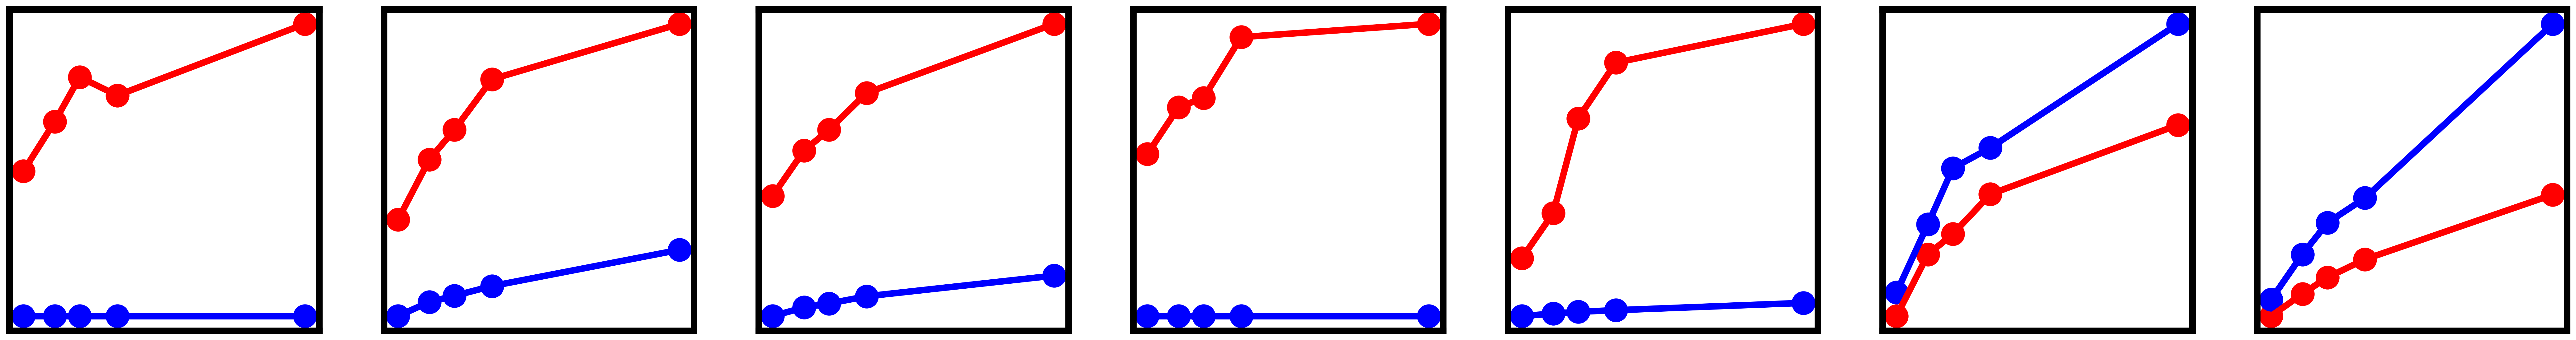

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# --- Fitting functions ---
def adsorption_ratio(x, n, k):
    x = np.asarray(x, dtype=float)
    return (k * (x**n))

def fit_adsorption_ratio(xdata, ydata, p0=(0.5, 1.0)):
    x = np.asarray(xdata, dtype=float)
    y = np.asarray(ydata, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        raise ValueError("Not enough finite points to perform the fit.")
    popt, pcov = curve_fit(adsorption_ratio, x[mask], y[mask], p0=p0, maxfev=5000)
    return popt, pcov

# --- New version with superscript in the legend ---
summary = []
color = ["red", "blue"]

n_cols = 14
n_rows = int(np.ceil(len(unique_acid) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4), dpi=300)
axes = axes.flatten()
plt.subplots_adjust(wspace=2, hspace=1)

for idx, acid_temp in enumerate(unique_acid):
    df_by_acid = df.loc[df["Acid"] == acid_temp]
    ax = axes[idx]
    count = 0
    for experiment_type in df_by_acid["Experiment"].unique():
        try:
            this_curve = df_by_acid.loc[df_by_acid["Experiment"] == experiment_type]
            x = this_curve["Acid conc (mM)"] / this_curve["FA conc (mM)"]
            y = this_curve["acid/SBU"] / this_curve["FA/SBU"]
            # Plot
            ax.scatter(x, y, color=color[count % len(color)], s=300)
            ax.plot(x, y, color=color[count % len(color)], linewidth=5) # line connecting them
            ax.set_xticks([])
            ax.set_yticks([])
            count += 1
            # ---- Set frame (spine) width ----
            for spine in ax.spines.values():
                spine.set_linewidth(5)       # <--- Adjust thickness here
                spine.set_edgecolor("black") # optional: make frame black

        except Exception as e:
            print(f"Error with {acid_temp}, {experiment_type}: {e}")
            count += 1

# Hide unused subplots
for i in range(len(unique_acid), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(pad=2.0, w_pad=5, h_pad=1.0)
plt.show()
